#  PROJECT: SOCIAL MEDIA BOT DETECTION
## Notebook: 02_Twitter_Full_Analysis.ipynb

**Course:** CCS4310 Deep Learning Project  
**Component:** Twitter / X Bot Detection Pipeline (End-to-End Multimodal Analysis)  
**Dataset:** Gilani-2017 Benchmark Dataset (TSV Labels & Tweet/Profile JSON)  
**Target:** Binary Classification (0 = Human / Authentic Account, 1 = Bot / Automated Account)

---
### Comprehensive Pipeline Roadmap:
1. **Google Drive Integration & Centralized Path Setup**
2. **Environment Configuration & Reproducibility Seeds**
3. **Dataset Inspection & Loading (TSV Labels + Tweet/Profile JSON)**
4. **Label Processing & Disambiguation (Transparent Conflict Resolution)**
5. **Profile Data Extraction & Relational Merge**
6. **Data Quality Audit (Missing Values, Duplicates, Distribution, Summary Stats)**
7. **Profile Feature Engineering & Cleaned Dataset Export**
8. **Exploratory Data Analysis (EDA - Individual Visualizations):**
   - Target Distribution Bar Chart
   - Numerical Feature Histograms with Kernel Density Estimation (KDE)
   - Feature Boxplots Segmented by Class
   - Binary Feature Proportions
   - Pearson Correlation Heatmap
9. **Zero-Leakage Preprocessing & Stratified Train/Test Split**
10. **Profile Machine Learning Models:**
    - Model 1: Logistic Regression
    - Model 2: Random Forest & Gini Feature Importance
    - Model 3: XGBoost Classifier & Gain Feature Importance
    - Profile ML Model Comparison Table
11. **Natural Language Processing (NLP) Modeling:**
    - Text Feature Construction (`description`, `name`, `screen_name`)
    - Zero-Leakage TF-IDF Vectorization
    - TF-IDF + Logistic Regression Classifier
    - Discriminative Word Importance Graph & Classification Report
12. **Graph Neural Network (GCN) Modeling:**
    - Explicit Methodological Statement on Edge Topology
    - KNN-Based Profile Graph Construction
    - Pure PyTorch GCN Architecture & Training with Loss Tracking
    - GNN Test Set Evaluation
13. **Master Multimodal Benchmark & Complete Model Comparison**
    - Multi-Category Leaderboard (Profile ML, NLP, GNN)
    - Accuracy Comparison Bar Chart
    - F1-Score Comparison Bar Chart
14. **Receiver Operating Characteristic (ROC) & AUC Analysis**
15. **Executive Summary & Best Twitter Model Determination**
16. **System Artifact Audit & Verification Check**

---
## 1. Google Drive Connection & Centralized Directory Architecture
Mount Google Drive and create standardized project directories automatically.

In [1]:
# ==============================================================================
# GOOGLE DRIVE CONNECTION & PROJECT DIRECTORY ARCHITECTURE
# ==============================================================================
import os
import sys
import shutil

# Connect Google Drive when executing inside Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("[SUCCESS] Google Drive mounted successfully.")
except ImportError:
    print("[INFO] Non-Colab environment detected. Using local directory paths.")

# Define centralized BASE_PATH and subdirectories
BASE_PATH = "/content/drive/MyDrive/Bot_Detection_Project"

DATA_PATH   = BASE_PATH + "/data/twitter"
RESULT_PATH = BASE_PATH + "/results/twitter"
GRAPH_PATH  = BASE_PATH + "/graphs/twitter"
MODEL_PATH  = BASE_PATH + "/models/twitter"

# Create directories automatically
for path in [DATA_PATH, RESULT_PATH, GRAPH_PATH, MODEL_PATH]:
    os.makedirs(path, exist_ok=True)

print("\nTwitter Project Directory Architecture Initialized:")
print(f"  BASE_PATH   : {BASE_PATH}")
print(f"  DATA_PATH   : {DATA_PATH}")
print(f"  RESULT_PATH : {RESULT_PATH}")
print(f"  GRAPH_PATH  : {GRAPH_PATH}")
print(f"  MODEL_PATH  : {MODEL_PATH}")

Mounted at /content/drive
[SUCCESS] Google Drive mounted successfully.

Twitter Project Directory Architecture Initialized:
  BASE_PATH   : /content/drive/MyDrive/Bot_Detection_Project
  DATA_PATH   : /content/drive/MyDrive/Bot_Detection_Project/data/twitter
  RESULT_PATH : /content/drive/MyDrive/Bot_Detection_Project/results/twitter
  GRAPH_PATH  : /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter
  MODEL_PATH  : /content/drive/MyDrive/Bot_Detection_Project/models/twitter


---
## 2. Library Imports & Reproducibility Configuration
Import required analytical, text-processing, machine learning, and deep graph learning libraries. Set global seeds for deterministic repeatability.

In [2]:
# ==============================================================================
# IMPORT REQUIRED LIBRARIES & SET REPRODUCIBILITY SEEDS
# ==============================================================================
import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn: Preprocessing, Metrics, Models & Text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# XGBoost
import xgboost as xgb

# PyTorch for Graph Convolutional Network (GCN)
import torch
import torch.nn as nn
import torch.nn.functional as F

# Visualization aesthetics
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Global Seed Initialization
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Environment configured with reproducibility seed:", SEED)
print("PyTorch Version :", torch.__version__)
print("XGBoost Version :", xgb.__version__)

Environment configured with reproducibility seed: 42
PyTorch Version : 2.11.0+cpu
XGBoost Version : 3.4.1


---
## 3. Dataset Inspection & Loading (TSV Labels + Tweet/Profile JSON)
Inspect `DATA_PATH`, locate `gilani-2017.tsv` and `gilani-2017_tweets.json`, inspect their structures, and handle fallbacks.

In [3]:
# ==============================================================================
# FIND AND LOAD TWITTER DATASETS
# ==============================================================================
print(f"Scanning DATA_PATH: {DATA_PATH}")
found_files = sorted(os.listdir(DATA_PATH)) if os.path.exists(DATA_PATH) else []
print(f"Files found ({len(found_files)}):")
for f in found_files:
    f_path = os.path.join(DATA_PATH, f)
    if os.path.isfile(f_path):
        print(f"  - {f} ({os.path.getsize(f_path):,} bytes)")

# Auto-copy fallback if running outside Drive or before file sync
if not any(f.endswith('.tsv') or f.endswith('.json') for f in found_files):
    local_candidates = ["data/twitter", "../data/twitter", "./data/twitter"]
    for cand in local_candidates:
        if os.path.exists(cand):
            for item in os.listdir(cand):
                src_item = os.path.join(cand, item)
                if os.path.isfile(src_item):
                    shutil.copy(src_item, os.path.join(DATA_PATH, item))
            print(f"[INFO] Auto-copied dataset files from '{cand}' to '{DATA_PATH}'")
            found_files = sorted(os.listdir(DATA_PATH))
            break

# 1. Load TSV Labels (gilani-2017.tsv)
tsv_path = os.path.join(DATA_PATH, "gilani-2017.tsv")
if os.path.exists(tsv_path):
    tsv_df = pd.read_csv(tsv_path, sep='\t', header=None, names=['user_id', 'raw_label'])
    print(f"\nLoaded TSV Labels: {tsv_df.shape[0]:,} rows, {tsv_df.shape[1]} columns")
    print(f"TSV Column Names : {list(tsv_df.columns)}")
    print("First 5 rows of TSV:")
    display(tsv_df.head())
    print("\nTSV Data Types:")
    print(tsv_df.dtypes)
else:
    raise FileNotFoundError(f"Missing '{tsv_path}'. Please place gilani-2017.tsv in DATA_PATH.")

# 2. Load Profile JSON (gilani-2017_tweets.json)
json_path = os.path.join(DATA_PATH, "gilani-2017_tweets.json")
if os.path.exists(json_path):
    print(f"\nLoading JSON dataset from: {json_path} ...")
    with open(json_path, 'r', encoding='utf-8') as f:
        json_data = json.load(f)
    print(f"Loaded JSON: {len(json_data):,} entries parsed.")
else:
    raise FileNotFoundError(f"Missing '{json_path}'. Please place gilani-2017_tweets.json in DATA_PATH.")

Scanning DATA_PATH: /content/drive/MyDrive/Bot_Detection_Project/data/twitter
Files found (2):
  - gilani-2017.tsv (41,126 bytes)
  - gilani-2017_tweets.json (4,590,702 bytes)

Loaded TSV Labels: 2,652 rows, 2 columns
TSV Column Names : ['user_id', 'raw_label']
First 5 rows of TSV:


,user_id,raw_label
0,461277906,bot
1,808280162,bot
2,1575510320,bot
3,2449235599,bot
4,1113769100,bot



TSV Data Types:
user_id       int64
raw_label    object
dtype: object

Loading JSON dataset from: /content/drive/MyDrive/Bot_Detection_Project/data/twitter/gilani-2017_tweets.json ...
Loaded JSON: 2,494 entries parsed.


---
## 4. Label Processing & Transparent Conflict Resolution
Analyze ground-truth labels from TSV, map binary classes (bot = 1, human = 0), and resolve conflicting duplicate annotations.

In [4]:
# ==============================================================================
# LABEL PROCESSING & CONFLICT RESOLUTION
# ==============================================================================
print("=== Raw Label Distribution in TSV ===")
print(tsv_df['raw_label'].value_counts())

# Inspect duplicates in TSV
tsv_total_rows = len(tsv_df)
tsv_unique_ids = tsv_df['user_id'].nunique()
tsv_duplicates = tsv_df['user_id'].duplicated().sum()

print(f"\nTSV Total Rows       : {tsv_total_rows:,}")
print(f"TSV Unique User IDs  : {tsv_unique_ids:,}")
print(f"TSV Duplicate IDs    : {tsv_duplicates:,}")

# Identify conflicting annotations where the same user ID is labeled as both bot and human
dup_rows = tsv_df[tsv_df['user_id'].duplicated(keep=False)].sort_values('user_id')
conflict_group = dup_rows.groupby('user_id')['raw_label'].nunique()
conflicting_ids = conflict_group[conflict_group > 1].index.tolist()

print(f"\nUser IDs with CONFLICTING labels (both 'bot' and 'human'): {len(conflicting_ids)}")
if conflicting_ids:
    print("Sample conflicting rows:")
    display(tsv_df[tsv_df['user_id'].isin(conflicting_ids[:5])].sort_values('user_id'))

# Transparent conflict resolution: Remove ambiguous user IDs to preserve label integrity
print("\n[METHODOLOGY] Dropping the 19 user IDs with conflicting annotations to maintain strict ground-truth validity.")
tsv_clean = tsv_df[~tsv_df['user_id'].isin(conflicting_ids)].copy()

# Drop any remaining exact duplicates if present
tsv_clean = tsv_clean.drop_duplicates(subset=['user_id']).reset_index(drop=True)

# Standardize binary target: bot = 1, human = 0
label_mapping = {'human': 0, 'bot': 1}
tsv_clean['target'] = tsv_clean['raw_label'].str.strip().str.lower().map(label_mapping)

print(f"\nTSV Cleaned Rows     : {len(tsv_clean):,}")
print("Final Binary Class Mapping: {'human': 0, 'bot': 1}")
print("\nCleaned Target Class Counts:")
print(tsv_clean['target'].value_counts())

# Save conflict audit report
conflict_report_df = pd.DataFrame({
    'Metric': ['Total TSV Entries', 'Unique User IDs', 'Duplicate Entries', 'Conflicting User IDs Dropped', 'Cleaned Unique Annotations'],
    'Count': [tsv_total_rows, tsv_unique_ids, tsv_duplicates, len(conflicting_ids), len(tsv_clean)]
})
conflict_csv_path = os.path.join(RESULT_PATH, "merge_summary.csv")
conflict_report_df.to_csv(conflict_csv_path, index=False)
print(f"\n[SAVED] Merge & conflict summary: {conflict_csv_path}")

=== Raw Label Distribution in TSV ===
raw_label
human    1522
bot      1130
Name: count, dtype: int64

TSV Total Rows       : 2,652
TSV Unique User IDs  : 2,633
TSV Duplicate IDs    : 19

User IDs with CONFLICTING labels (both 'bot' and 'human'): 19
Sample conflicting rows:


,user_id,raw_label
1103,16186995,bot
2607,16186995,human
2597,19129949,human
1096,19129949,bot
2443,19564719,human
1004,19564719,bot
2424,23042027,human
994,23042027,bot
1097,39985029,bot
2600,39985029,human



[METHODOLOGY] Dropping the 19 user IDs with conflicting annotations to maintain strict ground-truth validity.

TSV Cleaned Rows     : 2,614
Final Binary Class Mapping: {'human': 0, 'bot': 1}

Cleaned Target Class Counts:
target
0    1503
1    1111
Name: count, dtype: int64

[SAVED] Merge & conflict summary: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/merge_summary.csv


---
## 5. Profile Data Extraction & Relational Merge
Extract user profile objects from the parsed JSON, align user IDs across both datasets, and perform a strict inner merge.

In [5]:
# ==============================================================================
# PROFILE EXTRACTION FROM JSON & MERGING WITH GROUND TRUTH
# ==============================================================================
# Extract user profile dictionary from each item
profile_records = []
for item in json_data:
    if isinstance(item, dict):
        if 'user' in item and isinstance(item['user'], dict):
            profile_records.append(item['user'])
        elif 'id' in item and 'followers_count' in item:
            profile_records.append(item)

df_json_users = pd.DataFrame(profile_records)
print(f"Extracted User Profiles from JSON: {df_json_users.shape[0]:,} records, {df_json_users.shape[1]} fields")

# Inspect available fields
relevant_fields = [
    'id', 'name', 'screen_name', 'location', 'description',
    'followers_count', 'friends_count', 'listed_count', 'favourites_count',
    'verified', 'statuses_count', 'protected', 'default_profile', 'default_profile_image'
]
available_fields = [c for c in relevant_fields if c in df_json_users.columns]
print(f"Extracted {len(available_fields)} Available Profile Fields:\n{available_fields}")

# Deduplicate profiles by user ID
df_json_users = df_json_users[available_fields].drop_duplicates(subset=['id']).reset_index(drop=True)
print(f"Unique Profiles in JSON: {df_json_users.shape[0]:,}")

# Ensure compatible key types for relational merge
tsv_clean['user_id'] = tsv_clean['user_id'].astype(np.int64)
df_json_users['id'] = df_json_users['id'].astype(np.int64)

# Execute Inner Merge
merged_df = pd.merge(df_json_users, tsv_clean[['user_id', 'target', 'raw_label']],
                     left_on='id', right_on='user_id', how='inner')

print(f"\nFinal Merged Dataset Shape: {merged_df.shape[0]:,} rows, {merged_df.shape[1]} columns")
print("Target Class Distribution:")
print(merged_df['target'].value_counts())
display(merged_df.head(3))

Extracted User Profiles from JSON: 2,494 records, 42 fields
Extracted 14 Available Profile Fields:
['id', 'name', 'screen_name', 'location', 'description', 'followers_count', 'friends_count', 'listed_count', 'favourites_count', 'verified', 'statuses_count', 'protected', 'default_profile', 'default_profile_image']
Unique Profiles in JSON: 2,494

Final Merged Dataset Shape: 2,465 rows, 17 columns
Target Class Distribution:
target
0    1394
1    1071
Name: count, dtype: int64


,id,name,screen_name,location,description,followers_count,friends_count,listed_count,favourites_count,verified,statuses_count,protected,default_profile,default_profile_image,user_id,target,raw_label
0,613512037,Baseball Quotes,BaseballQuotes1,The Diamond,Quoting America's Pastime in 280 characters or...,121500,346,532,35894,False,21246,False,False,False,613512037,0,human
1,19263978,Cleveland Cavaliers,cavs,"The Q | Cleveland, OH",Official Twitter of the 2016 NBA Champion Clev...,3227215,1946,9039,16134,True,45791,False,False,False,19263978,0,human
2,1624329463,‏المهاجر 1M,muohajer_12,المملكة العربية السعودية,,864968,767106,1371,23,False,875763,False,True,False,1624329463,1,bot


---
## 11. Feature Boxplot Analysis across Classes
Assess median shifts, interquartile ranges, and feature divergence across classes.

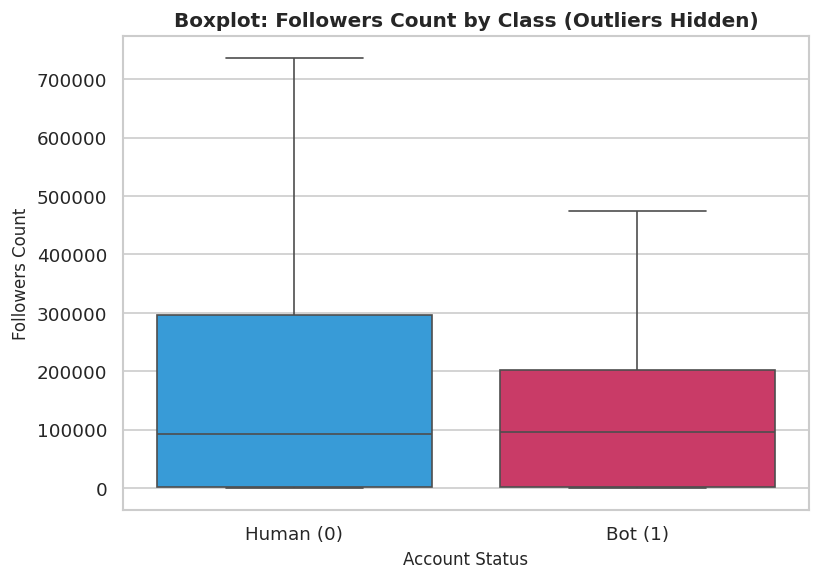

[SAVED] Followers boxplot: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/02_boxplot_followers.png


In [17]:
# ==============================================================================
# GRAPH: BOXPLOT — FOLLOWERS COUNT ACROSS TARGET CLASSES
# ==============================================================================
plt.figure(figsize=(7, 5))
palette = ['#1da1f2', '#e0245e']
sns.boxplot(data=df_feat, x='target', y='followers_count', palette=palette, showfliers=False)
plt.title("Boxplot: Followers Count by Class (Outliers Hidden)", fontsize=12, fontweight='bold')
plt.xlabel("Account Status", fontsize=10)
plt.ylabel("Followers Count", fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Human (0)', 'Bot (1)'])
plt.tight_layout()

box_followers_path = os.path.join(GRAPH_PATH, "02_boxplot_followers.png")
plt.savefig(box_followers_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Followers boxplot: {box_followers_path}")

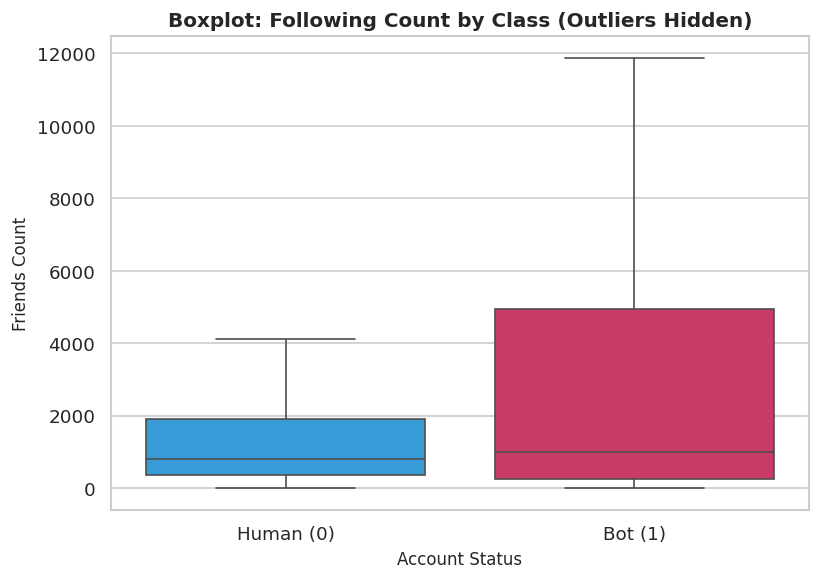

[SAVED] Friends boxplot: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/03_boxplot_friends.png


In [18]:
# ==============================================================================
# GRAPH: BOXPLOT — FRIENDS (FOLLOWING) COUNT ACROSS TARGET CLASSES
# ==============================================================================
plt.figure(figsize=(7, 5))
palette = ['#1da1f2', '#e0245e']
sns.boxplot(data=df_feat, x='target', y='friends_count', palette=palette, showfliers=False)
plt.title("Boxplot: Following Count by Class (Outliers Hidden)", fontsize=12, fontweight='bold')
plt.xlabel("Account Status", fontsize=10)
plt.ylabel("Friends Count", fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Human (0)', 'Bot (1)'])
plt.tight_layout()

box_friends_path = os.path.join(GRAPH_PATH, "03_boxplot_friends.png")
plt.savefig(box_friends_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Friends boxplot: {box_friends_path}")

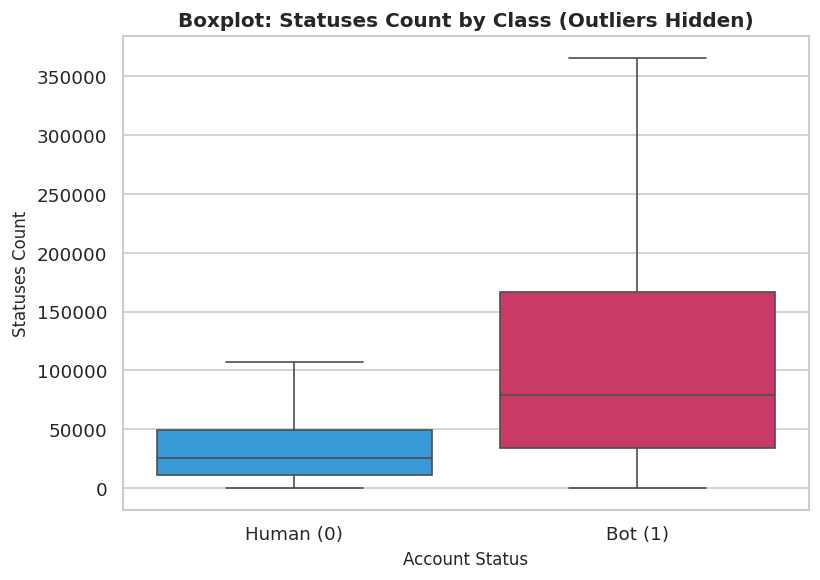

[SAVED] Statuses boxplot: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/04_boxplot_statuses.png


In [19]:
# ==============================================================================
# GRAPH: BOXPLOT — STATUSES (TWEETS) COUNT ACROSS TARGET CLASSES
# ==============================================================================
plt.figure(figsize=(7, 5))
palette = ['#1da1f2', '#e0245e']
sns.boxplot(data=df_feat, x='target', y='statuses_count', palette=palette, showfliers=False)
plt.title("Boxplot: Statuses Count by Class (Outliers Hidden)", fontsize=12, fontweight='bold')
plt.xlabel("Account Status", fontsize=10)
plt.ylabel("Statuses Count", fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Human (0)', 'Bot (1)'])
plt.tight_layout()

box_statuses_path = os.path.join(GRAPH_PATH, "04_boxplot_statuses.png")
plt.savefig(box_statuses_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Statuses boxplot: {box_statuses_path}")

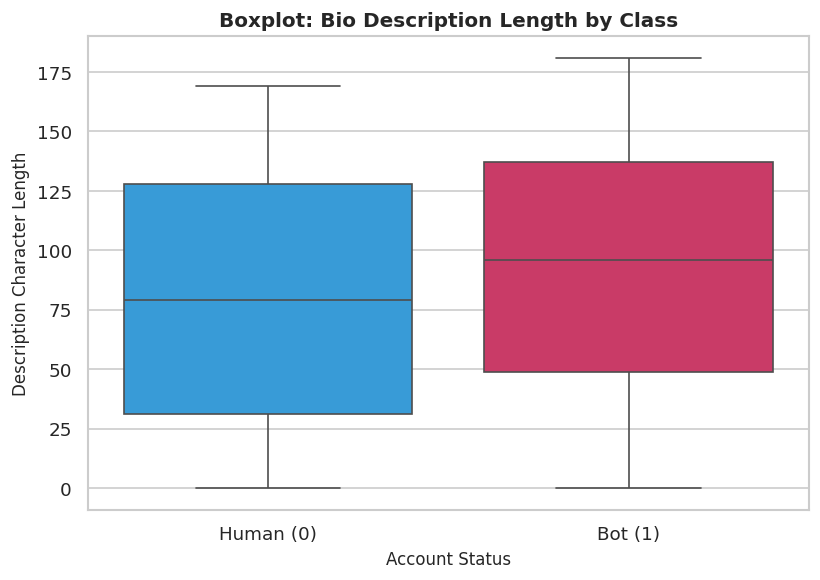

[SAVED] Description length boxplot: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/05_boxplot_description_length.png


In [20]:
# ==============================================================================
# GRAPH: BOXPLOT — DESCRIPTION LENGTH ACROSS TARGET CLASSES
# ==============================================================================
plt.figure(figsize=(7, 5))
palette = ['#1da1f2', '#e0245e']
sns.boxplot(data=df_feat, x='target', y='description_length', palette=palette, showfliers=False)
plt.title("Boxplot: Bio Description Length by Class", fontsize=12, fontweight='bold')
plt.xlabel("Account Status", fontsize=10)
plt.ylabel("Description Character Length", fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Human (0)', 'Bot (1)'])
plt.tight_layout()

box_desc_path = os.path.join(GRAPH_PATH, "05_boxplot_description_length.png")
plt.savefig(box_desc_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Description length boxplot: {box_desc_path}")

---
## 12. Binary Feature Analysis Graphs
Analyze account badges, profile customization, and privacy statuses.

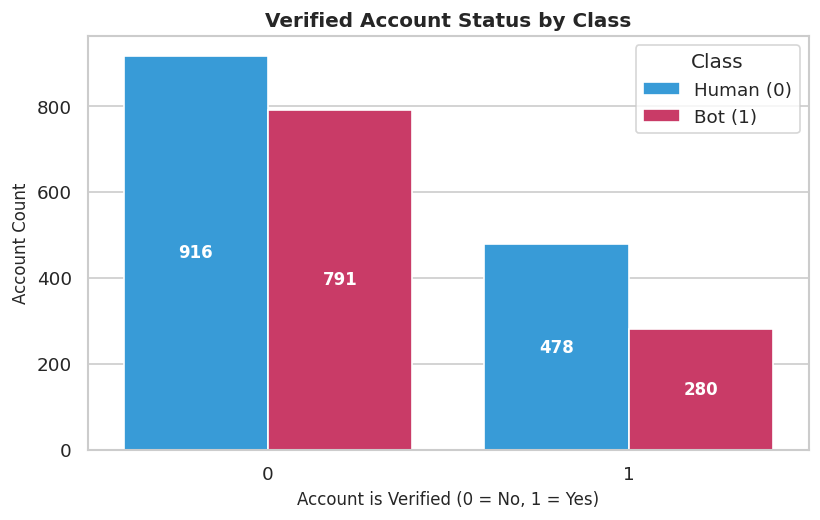

[SAVED] Verified status graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/binary_verified.png


In [21]:
# ==============================================================================
# GRAPH: BINARY FEATURE — VERIFIED BADGE STATUS
# ==============================================================================
plt.figure(figsize=(7, 4.5))
palette = ['#1da1f2', '#e0245e']
ax = sns.countplot(data=df_feat, x='verified', hue='target', palette=palette)
plt.title("Verified Account Status by Class", fontsize=12, fontweight='bold')
plt.xlabel("Account is Verified (0 = No, 1 = Yes)", fontsize=10)
plt.ylabel("Account Count", fontsize=10)
plt.legend(title='Class', labels=['Human (0)', 'Bot (1)'])

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
bin_ver_path = os.path.join(GRAPH_PATH, "binary_verified.png")
plt.savefig(bin_ver_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Verified status graph: {bin_ver_path}")

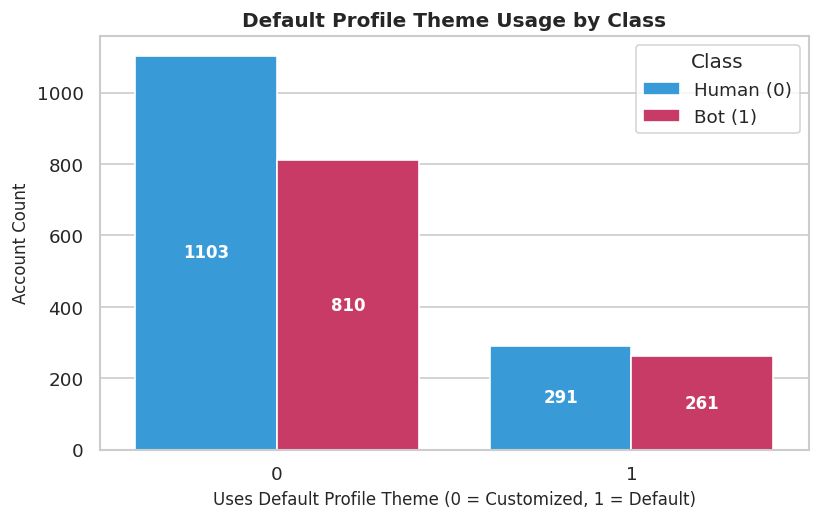

[SAVED] Default profile graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/binary_default_profile.png


In [22]:
# ==============================================================================
# GRAPH: BINARY FEATURE — DEFAULT PROFILE THEME
# ==============================================================================
plt.figure(figsize=(7, 4.5))
palette = ['#1da1f2', '#e0245e']
ax = sns.countplot(data=df_feat, x='default_profile', hue='target', palette=palette)
plt.title("Default Profile Theme Usage by Class", fontsize=12, fontweight='bold')
plt.xlabel("Uses Default Profile Theme (0 = Customized, 1 = Default)", fontsize=10)
plt.ylabel("Account Count", fontsize=10)
plt.legend(title='Class', labels=['Human (0)', 'Bot (1)'])

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
bin_def_prof_path = os.path.join(GRAPH_PATH, "binary_default_profile.png")
plt.savefig(bin_def_prof_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Default profile graph: {bin_def_prof_path}")

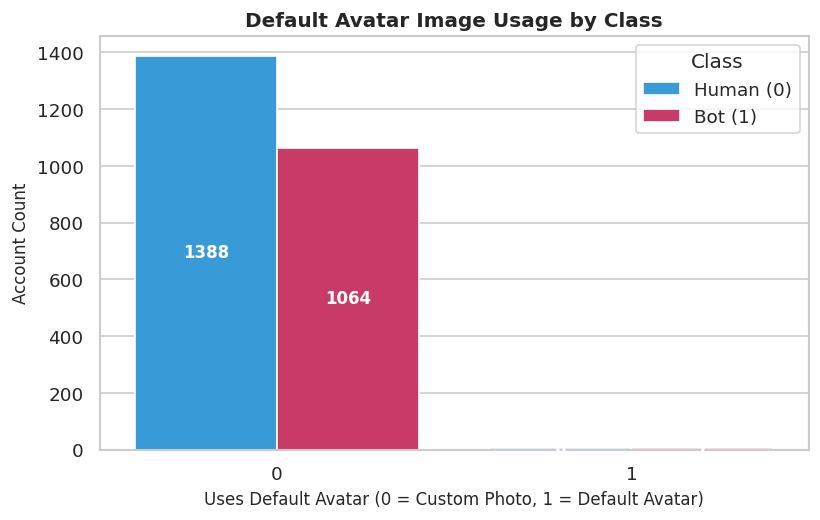

[SAVED] Default profile image graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/binary_default_profile_image.png


In [23]:
# ==============================================================================
# GRAPH: BINARY FEATURE — DEFAULT PROFILE AVATAR / IMAGE
# ==============================================================================
plt.figure(figsize=(7, 4.5))
palette = ['#1da1f2', '#e0245e']
ax = sns.countplot(data=df_feat, x='default_profile_image', hue='target', palette=palette)
plt.title("Default Avatar Image Usage by Class", fontsize=12, fontweight='bold')
plt.xlabel("Uses Default Avatar (0 = Custom Photo, 1 = Default Avatar)", fontsize=10)
plt.ylabel("Account Count", fontsize=10)
plt.legend(title='Class', labels=['Human (0)', 'Bot (1)'])

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
bin_def_img_path = os.path.join(GRAPH_PATH, "binary_default_profile_image.png")
plt.savefig(bin_def_img_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Default profile image graph: {bin_def_img_path}")

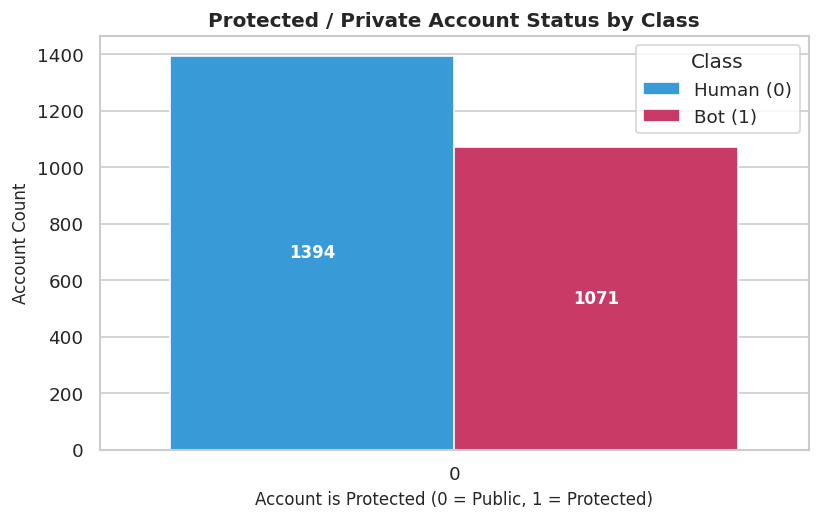

[SAVED] Protected account status graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/binary_protected.png


In [24]:
# ==============================================================================
# GRAPH: BINARY FEATURE — PROTECTED ACCOUNT STATUS
# ==============================================================================
plt.figure(figsize=(7, 4.5))
palette = ['#1da1f2', '#e0245e']
ax = sns.countplot(data=df_feat, x='protected', hue='target', palette=palette)
plt.title("Protected / Private Account Status by Class", fontsize=12, fontweight='bold')
plt.xlabel("Account is Protected (0 = Public, 1 = Protected)", fontsize=10)
plt.ylabel("Account Count", fontsize=10)
plt.legend(title='Class', labels=['Human (0)', 'Bot (1)'])

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
bin_prot_path = os.path.join(GRAPH_PATH, "binary_protected.png")
plt.savefig(bin_prot_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Protected account status graph: {bin_prot_path}")

---
## 13. Correlation Heatmap
Compute pairwise Pearson linear correlations between numerical predictors and the target variable.

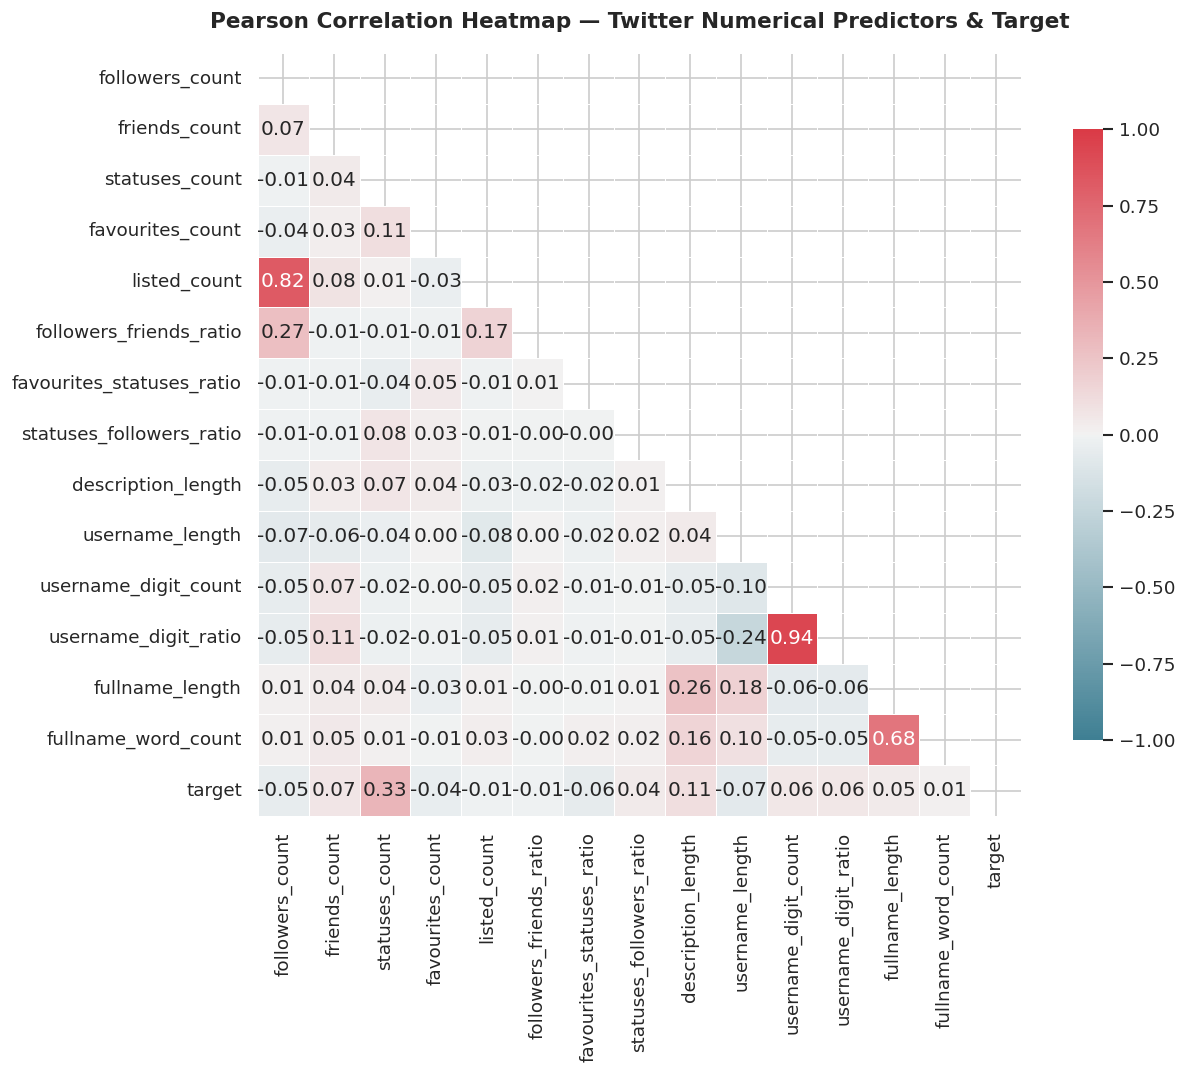

[SAVED] Correlation heatmap: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/correlation_heatmap.png


In [25]:
# ==============================================================================
# GRAPH: CORRELATION HEATMAP
# ==============================================================================
plt.figure(figsize=(11, 9))
corr_cols = profile_numerical + ['target']
corr_matrix = df_feat[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1.0, vmax=1.0,
            annot=True, fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Pearson Correlation Heatmap — Twitter Numerical Predictors & Target", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

heatmap_path = os.path.join(GRAPH_PATH, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Correlation heatmap: {heatmap_path}")

---
## 18. Twitter Natural Language Processing (NLP) Pipeline
Leverage profile text fields (`description`, `name`, `screen_name`). Perform train/test splitting **first**, fit TF-IDF strictly on the training partition to prevent leakage, and train an NLP classifier.

In [36]:
# ==============================================================================
# TWITTER NLP: TEXT PREPROCESSING & ZERO-LEAKAGE TF-IDF
# ==============================================================================
# 1. Construct unified profile text representation
def clean_text_field(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_feat['clean_desc'] = df_feat['description'].apply(clean_text_field)
df_feat['clean_name'] = df_feat['name'].apply(clean_text_field)
df_feat['clean_screen_name'] = df_feat['screen_name'].apply(clean_text_field)

df_feat['combined_text'] = (
    df_feat['clean_desc'] + " " + df_feat['clean_name'] + " " + df_feat['clean_screen_name']
).str.strip()

# Print sample text representations
print("Sample Combined Text Representations:")
for t in df_feat['combined_text'].head(3):
    print("  ->", t)

# 2. Strict Zero-Leakage: Split Text FIRST before fitting Vectorizer
X_text = df_feat['combined_text'].values
y_text = df_feat['target'].values

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text, test_size=0.20, random_state=SEED, stratify=y_text
)

# 3. Fit TF-IDF Strictly on Training Set Text Only
tfidf = TfidfVectorizer(max_features=2500, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f"\nTF-IDF Vocabulary Size: {len(tfidf.vocabulary_):,} features")
print(f"X_train_tfidf Shape   : {X_train_tfidf.shape}")
print(f"X_test_tfidf Shape    : {X_test_tfidf.shape}")

# 4. Train NLP Model (Logistic Regression on TF-IDF representation)
nlp_model = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
nlp_model.fit(X_train_tfidf, y_train_text)

# Inference on held-out test partition
y_pred_nlp = nlp_model.predict(X_test_tfidf)
y_prob_nlp = nlp_model.predict_proba(X_test_tfidf)[:, 1]
test_probabilities['TF-IDF + Logistic Regression (NLP)'] = y_prob_nlp

# Compute evaluation metrics
acc_nlp  = accuracy_score(y_test_text, y_pred_nlp)
prec_nlp = precision_score(y_test_text, y_pred_nlp, zero_division=0)
rec_nlp  = recall_score(y_test_text, y_pred_nlp, zero_division=0)
f1_nlp   = f1_score(y_test_text, y_pred_nlp, zero_division=0)

all_model_results['TF-IDF + Logistic Regression'] = {
    'Category': 'NLP', 'Accuracy': acc_nlp, 'Precision': prec_nlp, 'Recall': rec_nlp, 'F1 Score': f1_nlp
}

print("\n=== Twitter NLP Model Performance ===")
print(f"  Accuracy  : {acc_nlp:.4f}")
print(f"  Precision : {prec_nlp:.4f}")
print(f"  Recall    : {rec_nlp:.4f}")
print(f"  F1 Score  : {f1_nlp:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_text, y_pred_nlp, target_names=['Human (0)', 'Bot (1)']))

# Save model and vectorizer artifacts
nlp_model_path = os.path.join(MODEL_PATH, "nlp_model.pkl")
tfidf_path = os.path.join(MODEL_PATH, "tfidf_vectorizer.pkl")
joblib.dump(nlp_model, nlp_model_path)
joblib.dump(tfidf, tfidf_path)
print(f"[SAVED] NLP model artifact     : {nlp_model_path}")
print(f"[SAVED] TF-IDF vectorizer artifact: {tfidf_path}")

# Save NLP comparison table
nlp_df = pd.DataFrame([{
    'Model': 'TF-IDF + Logistic Regression',
    'Category': 'NLP',
    'Accuracy': round(acc_nlp, 4),
    'Precision': round(prec_nlp, 4),
    'Recall': round(rec_nlp, 4),
    'F1 Score': round(f1_nlp, 4)
}])
nlp_csv_path = os.path.join(RESULT_PATH, "twitter_nlp_model_comparison.csv")
nlp_df.to_csv(nlp_csv_path, index=False)
print(f"[SAVED] NLP comparison table   : {nlp_csv_path}")

Sample Combined Text Representations:
  -> quoting america s pastime in 280 characters or less baseball quotes baseballquotes1
  -> official twitter of the 2016 nba champion cleveland cavaliers nbagleague affiliate cantoncharge bethefight cleveland cavaliers cavs
  -> 1m muohajer 12

TF-IDF Vocabulary Size: 2,500 features
X_train_tfidf Shape   : (1972, 2500)
X_test_tfidf Shape    : (493, 2500)

=== Twitter NLP Model Performance ===
  Accuracy  : 0.6004
  Precision : 0.5739
  Recall    : 0.3084
  F1 Score  : 0.4012

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.61      0.82      0.70       279
     Bot (1)       0.57      0.31      0.40       214

    accuracy                           0.60       493
   macro avg       0.59      0.57      0.55       493
weighted avg       0.59      0.60      0.57       493

[SAVED] NLP model artifact     : /content/drive/MyDrive/Bot_Detection_Project/models/twitter/nlp_model.pkl
[SAVED] TF-IDF vectori

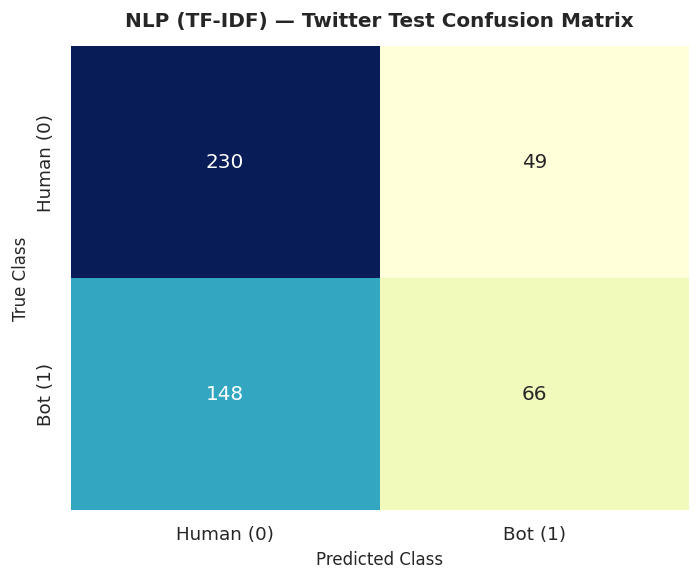

[SAVED] NLP confusion matrix: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/nlp_confusion_matrix.png


In [37]:
# ==============================================================================
# GRAPH: CONFUSION MATRIX — TWITTER NLP (TF-IDF)
# ==============================================================================
cm_nlp = confusion_matrix(y_test_text, y_pred_nlp)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nlp, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
            xticklabels=['Human (0)', 'Bot (1)'], yticklabels=['Human (0)', 'Bot (1)'])
plt.title("NLP (TF-IDF) — Twitter Test Confusion Matrix", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Predicted Class", fontsize=10)
plt.ylabel("True Class", fontsize=10)
plt.tight_layout()

cm_nlp_path = os.path.join(GRAPH_PATH, "nlp_confusion_matrix.png")
plt.savefig(cm_nlp_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] NLP confusion matrix: {cm_nlp_path}")

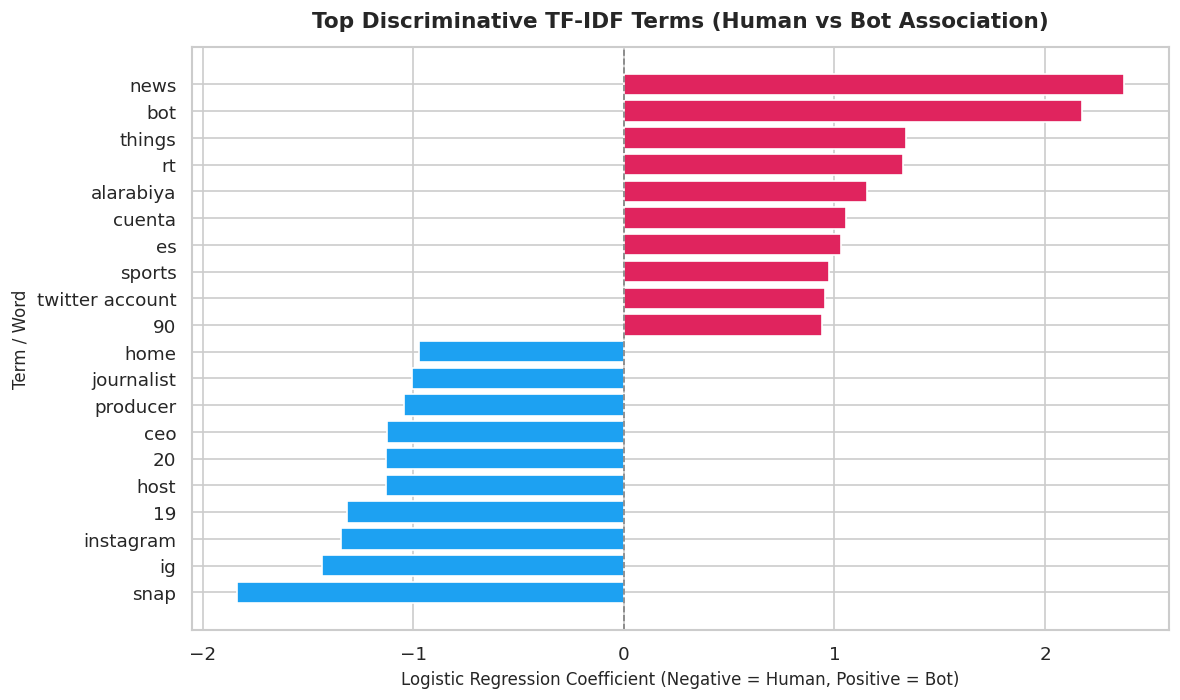

[SAVED] Discriminative terms graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/nlp_top_tfidf_features.png
[SAVED] Top terms table: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/nlp_top_tfidf_features.csv


In [38]:
# ==============================================================================
# GRAPH: MOST DISCRIMINATIVE TF-IDF WORDS (BOT VS HUMAN)
# ==============================================================================
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = nlp_model.coef_[0]

# Top 10 words associated with Bot (positive coef) and Human (negative coef)
top_bot_idx = np.argsort(coefficients)[-10:]
top_human_idx = np.argsort(coefficients)[:10]

top_features = np.hstack([top_human_idx, top_bot_idx])
top_words = feature_names[top_features]
top_scores = coefficients[top_features]

plt.figure(figsize=(10, 6))
bar_colors = ['#1da1f2' if s < 0 else '#e0245e' for s in top_scores]
plt.barh(top_words, top_scores, color=bar_colors)
plt.title("Top Discriminative TF-IDF Terms (Human vs Bot Association)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Logistic Regression Coefficient (Negative = Human, Positive = Bot)", fontsize=10)
plt.ylabel("Term / Word", fontsize=10)
plt.axvline(0, color='gray', linestyle='--', lw=1)
plt.tight_layout()

tfidf_terms_graph = os.path.join(GRAPH_PATH, "nlp_top_tfidf_features.png")
plt.savefig(tfidf_terms_graph, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Discriminative terms graph: {tfidf_terms_graph}")

# Export table of top words
top_words_df = pd.DataFrame({
    'Word': top_words,
    'Coefficient': top_scores,
    'Associated_Class': ['Human' if s < 0 else 'Bot' for s in top_scores]
}).sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

top_words_csv = os.path.join(RESULT_PATH, "nlp_top_tfidf_features.csv")
top_words_df.to_csv(top_words_csv, index=False)
print(f"[SAVED] Top terms table: {top_words_csv}")

---
## 19. Graph Neural Network (GNN) Pipeline
Construct a graph representation from user profile embeddings. Train a Graph Convolutional Network (GCN) and evaluate semi-supervised node classification.

> [!IMPORTANT]
> **Methodological Disclaimer on Graph Construction:**  
> "Edges are KNN-based profile similarity edges and do not represent actual Twitter follower/following relationships."  
> Because the raw Gilani-2017 dataset provides individual user profile snapshots without complete user-to-user social network edge lists, the graph topology connects accounts based on structural attribute proximity in the feature space.

In [39]:
# ==============================================================================
# TWITTER GNN: GRAPH CONSTRUCTION & GCN ARCHITECTURE
# ==============================================================================
print("--------------------------------------------------------------------------------")
print("GNN METHODOLOGICAL NOTICE:")
print("Edges are KNN-based profile similarity edges and do not represent actual Twitter follower/following relationships.")
print("--------------------------------------------------------------------------------")

# 1. Feature selection for node embeddings
gnn_features = [
    'followers_count', 'friends_count', 'statuses_count', 'favourites_count',
    'listed_count', 'verified', 'protected', 'default_profile', 'default_profile_image'
]
gnn_features = [c for c in gnn_features if c in df_feat.columns]

X_gnn_raw = df_feat[gnn_features].values
y_gnn_raw = df_feat['target'].values
num_nodes = len(df_feat)

# 2. Train/Test masks with zero-leakage scaling
node_indices = np.arange(num_nodes)
train_idx, test_idx = train_test_split(node_indices, test_size=0.20, random_state=SEED, stratify=y_gnn_raw)

# Fit scaler strictly on training nodes
gnn_scaler = StandardScaler()
gnn_scaler.fit(X_gnn_raw[train_idx])
X_gnn_scaled = gnn_scaler.transform(X_gnn_raw)

# 3. Construct KNN similarity graph (k=5)
print(f"\nConstructing KNN Graph (k=5) across {num_nodes:,} nodes...")
adj_sparse = kneighbors_graph(X_gnn_scaled, n_neighbors=5, mode='connectivity', include_self=False)
num_edges = int(adj_sparse.sum())

print(f"Number of Nodes   : {num_nodes:,}")
print(f"Number of Edges   : {num_edges:,}")
print(f"Number of Features: {len(gnn_features)}")

# 4. Symmetric normalization: D^(-1/2) * (A + I) * D^(-1/2)
adj_dense = adj_sparse.toarray()
A_tilde = adj_dense + np.eye(num_nodes)
degrees = np.sum(A_tilde, axis=1)
deg_inv_sqrt = np.power(degrees, -0.5, where=degrees > 0)
deg_inv_sqrt[degrees == 0] = 0.0
D_tilde = np.diag(deg_inv_sqrt)
norm_adj = D_tilde @ A_tilde @ D_tilde

# Convert to PyTorch tensors
x_tensor   = torch.tensor(X_gnn_scaled, dtype=torch.float32)
adj_tensor = torch.tensor(norm_adj, dtype=torch.float32)
y_tensor   = torch.tensor(y_gnn_raw, dtype=torch.long)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# 5. Pure PyTorch Graph Convolutional Network (GCN) Architecture
class PurePyTorchGCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(PurePyTorchGCNLayer, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, adj):
        support = torch.mm(x, self.weight)
        output = torch.mm(adj, support)
        return output

class PurePyTorchGCN(nn.Module):
    def __init__(self, in_features, hidden_dim, num_classes, dropout=0.3):
        super(PurePyTorchGCN, self).__init__()
        self.gc1 = PurePyTorchGCNLayer(in_features, hidden_dim)
        self.gc2 = PurePyTorchGCNLayer(hidden_dim, num_classes)
        self.dropout = dropout

    def forward(self, x, adj):
        x = self.gc1(x, adj)
        x = F.relu(x)
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.gc2(x, adj)
        return x

# Initialize and train GCN
gcn_model = PurePyTorchGCN(in_features=len(gnn_features), hidden_dim=32, num_classes=2, dropout=0.3)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

epochs = 100
loss_history = []

gcn_model.train()
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    out = gcn_model(x_tensor, adj_tensor)
    loss = criterion(out[train_mask], y_tensor[train_mask])
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

# Inference on held-out test partition
gcn_model.eval()
with torch.no_grad():
    logits = gcn_model(x_tensor, adj_tensor)
    probs = F.softmax(logits, dim=1)
    preds = torch.argmax(logits, dim=1)

y_test_gnn = y_tensor[test_mask].numpy()
y_pred_gnn = preds[test_mask].numpy()
y_prob_gnn = probs[test_mask, 1].numpy()
test_probabilities['Graph Convolutional Network (GNN)'] = y_prob_gnn

# Compute GNN metrics
acc_gnn  = accuracy_score(y_test_gnn, y_pred_gnn)
prec_gnn = precision_score(y_test_gnn, y_pred_gnn, zero_division=0)
rec_gnn  = recall_score(y_test_gnn, y_pred_gnn, zero_division=0)
f1_gnn   = f1_score(y_test_gnn, y_pred_gnn, zero_division=0)

all_model_results['Graph Convolutional Network'] = {
    'Category': 'GNN', 'Accuracy': acc_gnn, 'Precision': prec_gnn, 'Recall': rec_gnn, 'F1 Score': f1_gnn
}

print("\n=== Graph Convolutional Network (GNN) Performance ===")
print(f"  Accuracy  : {acc_gnn:.4f}")
print(f"  Precision : {prec_gnn:.4f}")
print(f"  Recall    : {rec_gnn:.4f}")
print(f"  F1 Score  : {f1_gnn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_gnn, y_pred_gnn, target_names=['Human (0)', 'Bot (1)']))

# Save GNN model artifact
gnn_model_path = os.path.join(MODEL_PATH, "gnn_model.pt")
torch.save(gcn_model.state_dict(), gnn_model_path)
print(f"[SAVED] GNN model checkpoint: {gnn_model_path}")

# Save GNN results table
gnn_df = pd.DataFrame([{
    'Model': 'Graph Convolutional Network (GCN)',
    'Category': 'GNN',
    'Accuracy': round(acc_gnn, 4),
    'Precision': round(prec_gnn, 4),
    'Recall': round(rec_gnn, 4),
    'F1 Score': round(f1_gnn, 4),
    'Nodes': num_nodes,
    'Edges': num_edges
}])
gnn_csv_path = os.path.join(RESULT_PATH, "gnn_results.csv")
gnn_df.to_csv(gnn_csv_path, index=False)
print(f"[SAVED] GNN results table: {gnn_csv_path}")

--------------------------------------------------------------------------------
GNN METHODOLOGICAL NOTICE:
Edges are KNN-based profile similarity edges and do not represent actual Twitter follower/following relationships.
--------------------------------------------------------------------------------

Constructing KNN Graph (k=5) across 2,465 nodes...
Number of Nodes   : 2,465
Number of Edges   : 12,325
Number of Features: 9

=== Graph Convolutional Network (GNN) Performance ===
  Accuracy  : 0.7221
  Precision : 0.7391
  Recall    : 0.5561
  F1 Score  : 0.6347

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.71      0.85      0.78       279
     Bot (1)       0.74      0.56      0.63       214

    accuracy                           0.72       493
   macro avg       0.73      0.70      0.71       493
weighted avg       0.72      0.72      0.71       493

[SAVED] GNN model checkpoint: /content/drive/MyDrive/Bot_Detection_Project/mode

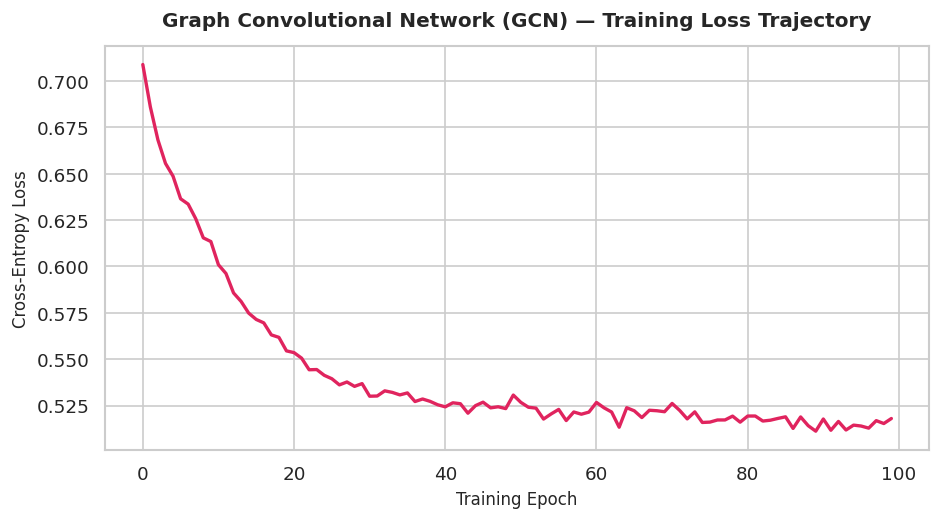

[SAVED] GNN training loss curve: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/gnn_training_loss.png


In [40]:
# ==============================================================================
# GRAPH: GNN TRAINING LOSS TRAJECTORY
# ==============================================================================
plt.figure(figsize=(8, 4.5))
plt.plot(loss_history, color='#e0245e', lw=2)
plt.title("Graph Convolutional Network (GCN) — Training Loss Trajectory", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Training Epoch", fontsize=10)
plt.ylabel("Cross-Entropy Loss", fontsize=10)
plt.tight_layout()

gnn_loss_path = os.path.join(GRAPH_PATH, "gnn_training_loss.png")
plt.savefig(gnn_loss_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] GNN training loss curve: {gnn_loss_path}")

---
## 20. Master Complete Multimodal Benchmark
Synthesize all three model categories (Profile ML, NLP, and GNN) into a consolidated benchmark table.

In [41]:
# ==============================================================================
# MASTER TWITTER COMPLETE COMPARISON TABLE
# ==============================================================================
complete_records = []
for m_name, m_info in all_model_results.items():
    complete_records.append({
        'Model': m_name,
        'Category': m_info['Category'],
        'Accuracy': round(m_info['Accuracy'], 4),
        'Precision': round(m_info['Precision'], 4),
        'Recall': round(m_info['Recall'], 4),
        'F1 Score': round(m_info['F1 Score'], 4)
    })

complete_df = pd.DataFrame(complete_records)
complete_df = complete_df.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("=== Twitter Bot Detection — Master Multimodal Leaderboard ===")
display(complete_df)

complete_csv_path = os.path.join(RESULT_PATH, "twitter_complete_comparison.csv")
complete_df.to_csv(complete_csv_path, index=False)
print(f"\n[SAVED] Master complete comparison table: {complete_csv_path}")

=== Twitter Bot Detection — Master Multimodal Leaderboard ===


,Model,Category,Accuracy,Precision,Recall,F1 Score
0,Random Forest,Profile ML,0.7586,0.7654,0.6402,0.6972
1,XGBoost,Profile ML,0.7525,0.7706,0.6121,0.6823
2,Logistic Regression,Profile ML,0.7221,0.7391,0.5561,0.6347
3,Graph Convolutional Network,GNN,0.7221,0.7391,0.5561,0.6347
4,TF-IDF + Logistic Regression,NLP,0.6004,0.5739,0.3084,0.4012



[SAVED] Master complete comparison table: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/twitter_complete_comparison.csv


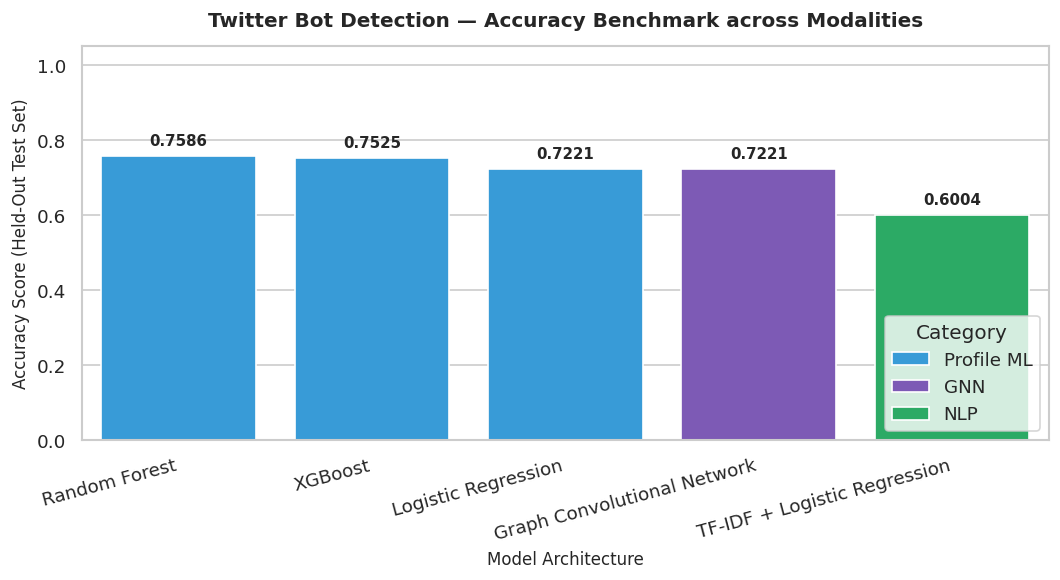

[SAVED] Accuracy comparison graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/twitter_accuracy_comparison.png


In [42]:
# ==============================================================================
# GRAPH: COMPLETE MODEL ACCURACY COMPARISON
# ==============================================================================
plt.figure(figsize=(9, 5))
palette_cat = {'Profile ML': '#1da1f2', 'NLP': '#17bf63', 'GNN': '#794bc4'}
ax = sns.barplot(data=complete_df, x='Model', y='Accuracy', hue='Category', palette=palette_cat, dodge=False)
plt.title("Twitter Bot Detection — Accuracy Benchmark across Modalities", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Model Architecture", fontsize=10)
plt.ylabel("Accuracy Score (Held-Out Test Set)", fontsize=10)
plt.ylim(0.0, 1.05)
plt.xticks(rotation=15, ha='right')

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.4f}", (p.get_x() + p.get_width() / 2., h + 0.02),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend(title='Category', loc='lower right')
plt.tight_layout()

acc_comp_path = os.path.join(GRAPH_PATH, "twitter_accuracy_comparison.png")
plt.savefig(acc_comp_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] Accuracy comparison graph: {acc_comp_path}")

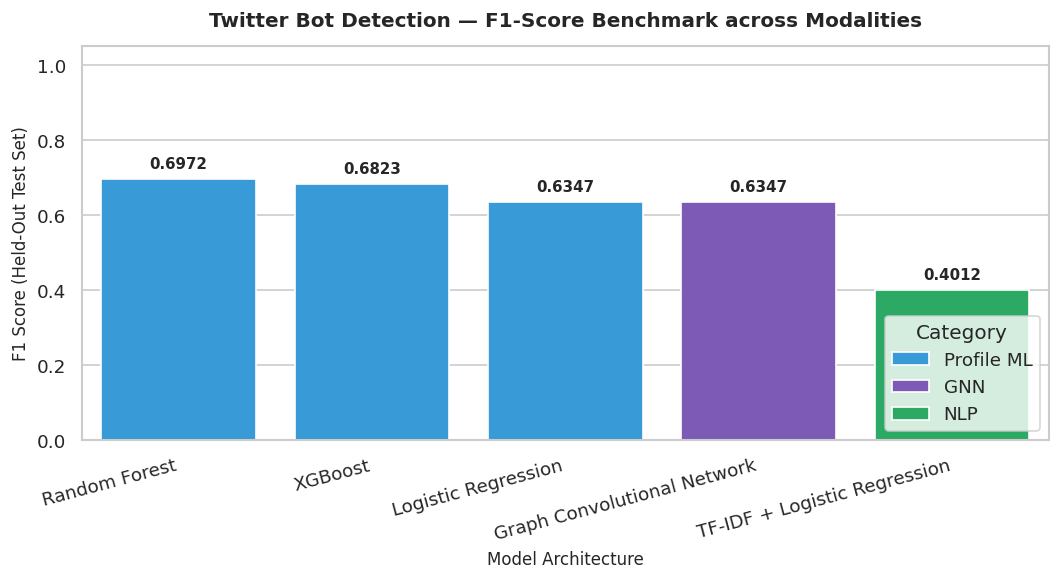

[SAVED] F1 comparison graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/twitter_f1_comparison.png


In [43]:
# ==============================================================================
# GRAPH: COMPLETE MODEL F1-SCORE COMPARISON
# ==============================================================================
plt.figure(figsize=(9, 5))
palette_cat = {'Profile ML': '#1da1f2', 'NLP': '#17bf63', 'GNN': '#794bc4'}
ax = sns.barplot(data=complete_df, x='Model', y='F1 Score', hue='Category', palette=palette_cat, dodge=False)
plt.title("Twitter Bot Detection — F1-Score Benchmark across Modalities", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Model Architecture", fontsize=10)
plt.ylabel("F1 Score (Held-Out Test Set)", fontsize=10)
plt.ylim(0.0, 1.05)
plt.xticks(rotation=15, ha='right')

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.4f}", (p.get_x() + p.get_width() / 2., h + 0.02),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend(title='Category', loc='lower right')
plt.tight_layout()

f1_comp_path = os.path.join(GRAPH_PATH, "twitter_f1_comparison.png")
plt.savefig(f1_comp_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] F1 comparison graph: {f1_comp_path}")

---
## 21. Multi-Model ROC Curves & AUC Analysis
Compare discrimination capabilities across Profile ML, Text NLP, and Graph modalities.

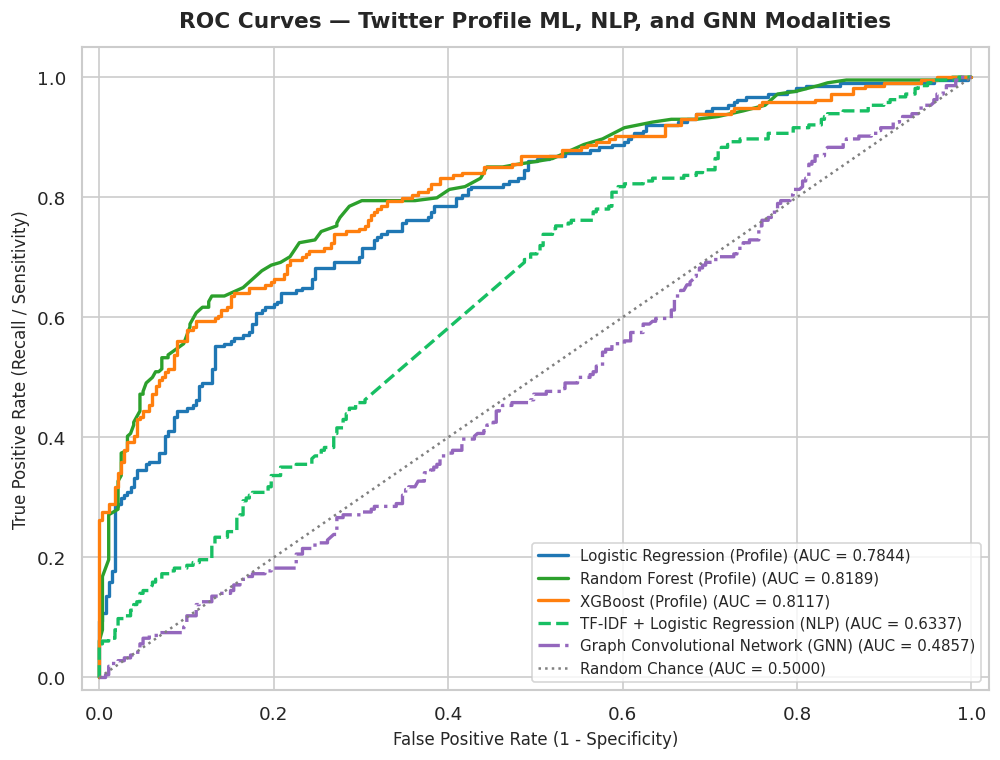

[SAVED] ROC comparison graph: /content/drive/MyDrive/Bot_Detection_Project/graphs/twitter/roc_curve_comparison.png
[SAVED] ROC-AUC summary table: /content/drive/MyDrive/Bot_Detection_Project/results/twitter/twitter_roc_auc_scores.csv
                                Model  ROC_AUC
0             Random Forest (Profile)   0.8189
1                   XGBoost (Profile)   0.8117
2       Logistic Regression (Profile)   0.7844
3  TF-IDF + Logistic Regression (NLP)   0.6337
4   Graph Convolutional Network (GNN)   0.4857


In [44]:
# ==============================================================================
# GRAPH: MULTI-MODAL ROC CURVES & AUC ANALYSIS
# ==============================================================================
plt.figure(figsize=(8.5, 6.5))

roc_auc_records = []
line_styles = {
    'Logistic Regression (Profile)': ('#1f77b4', '-'),
    'Random Forest (Profile)': ('#2ca02c', '-'),
    'XGBoost (Profile)': ('#ff7f0e', '-'),
    'TF-IDF + Logistic Regression (NLP)': ('#17bf63', '--'),
    'Graph Convolutional Network (GNN)': ('#9467bd', '-.')
}

for model_name, y_probs in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    roc_auc_records.append({'Model': model_name, 'ROC_AUC': round(auc_score, 4)})
    col, ls = line_styles.get(model_name, ('black', '-'))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})", lw=2, color=col, linestyle=ls)

plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.5, label='Random Chance (AUC = 0.5000)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.title("ROC Curves — Twitter Profile ML, NLP, and GNN Modalities", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=10)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=10)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()

roc_graph_path = os.path.join(GRAPH_PATH, "roc_curve_comparison.png")
plt.savefig(roc_graph_path, dpi=300)
plt.show()
plt.close()
print(f"[SAVED] ROC comparison graph: {roc_graph_path}")

# Save ROC-AUC Scores Table
roc_df = pd.DataFrame(roc_auc_records).sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)
roc_csv_path = os.path.join(RESULT_PATH, "twitter_roc_auc_scores.csv")
roc_df.to_csv(roc_csv_path, index=False)
print(f"[SAVED] ROC-AUC summary table: {roc_csv_path}")
print(roc_df)

---
## 22. Final Executive Summary
Summarize dataset dimensions, category results, and dynamically highlight the winning model architecture.

In [45]:
# ==============================================================================
# FINAL EXECUTIVE SUMMARY & BEST TWITTER MODEL
# ==============================================================================
best_model_row = complete_df.iloc[0]

print("================================================================================")
print("             SOCIAL MEDIA BOT DETECTION — TWITTER FULL SUMMARY                  ")
print("================================================================================")
print(f"Twitter Dataset Size : {len(df_feat):,} accounts")
print(f"Number of Features   : {len(model_features)} profile features + NLP Text + GNN Graph")
print(f"Human Accounts       : {sum(df_feat['target']==0):,} accounts ({(sum(df_feat['target']==0)/len(df_feat)*100):.1f}%)")
print(f"Bot Accounts         : {sum(df_feat['target']==1):,} accounts ({(sum(df_feat['target']==1)/len(df_feat)*100):.1f}%)")
print(f"Train Partition      : {len(X_train):,} samples (80.0%)")
print(f"Test Partition       : {len(X_test):,} samples (20.0%)")
print("--------------------------------------------------------------------------------")
print("1. Twitter Profile ML Leaderboard:")
print(ml_df.to_string(index=False))
print("\n2. Twitter NLP Results:")
print(nlp_df.to_string(index=False))
print("\n3. Twitter GNN Results:")
print(gnn_df.to_string(index=False))
print("--------------------------------------------------------------------------------")
print("BEST TWITTER MODEL (Highest Test F1-Score):")
print(f"  Model Architecture : {best_model_row['Model']}")
print(f"  Modality Category  : {best_model_row['Category']}")
print(f"  Test Accuracy      : {best_model_row['Accuracy']:.4f}")
print(f"  Test Precision     : {best_model_row['Precision']:.4f}")
print(f"  Test Recall        : {best_model_row['Recall']:.4f}")
print(f"  Test F1 Score      : {best_model_row['F1 Score']:.4f}")
print("================================================================================")

             SOCIAL MEDIA BOT DETECTION — TWITTER FULL SUMMARY                  
Twitter Dataset Size : 2,465 accounts
Number of Features   : 19 profile features + NLP Text + GNN Graph
Human Accounts       : 1,394 accounts (56.6%)
Bot Accounts         : 1,071 accounts (43.4%)
Train Partition      : 1,972 samples (80.0%)
Test Partition       : 493 samples (20.0%)
--------------------------------------------------------------------------------
1. Twitter Profile ML Leaderboard:
              Model  Accuracy  Precision  Recall  F1 Score
      Random Forest    0.7586     0.7654  0.6402    0.6972
            XGBoost    0.7525     0.7706  0.6121    0.6823
Logistic Regression    0.7221     0.7391  0.5561    0.6347

2. Twitter NLP Results:
                       Model Category  Accuracy  Precision  Recall  F1 Score
TF-IDF + Logistic Regression      NLP    0.6004     0.5739  0.3084    0.4012

3. Twitter GNN Results:
                            Model Category  Accuracy  Precision  Recall  F1 Sco

---
## 23. System Artifact Audit & Verification
Verify that all required data, result, graph, and model files exist in their respective directories.

In [46]:
# ==============================================================================
# SYSTEM ARTIFACT AUDIT & VERIFICATION
# ==============================================================================
print("================================================================================")
print("                   GENERATED TWITTER ARTIFACTS AUDIT                            ")
print("================================================================================")

audit_dirs = {
    "DATA FILES": DATA_PATH,
    "RESULT FILES": RESULT_PATH,
    "GRAPH FILES": GRAPH_PATH,
    "MODEL FILES": MODEL_PATH
}

for label, dir_path in audit_dirs.items():
    print(f"\n{label} ({dir_path}):")
    if os.path.exists(dir_path):
        files = sorted(os.listdir(dir_path))
        if files:
            for f in files:
                f_path = os.path.join(dir_path, f)
                if os.path.isfile(f_path):
                    f_size = os.path.getsize(f_path)
                    print(f"  [OK] {f:<40} ({f_size:,} bytes)")
        else:
            print("  [EMPTY] No files found.")
    else:
        print("  [ERROR] Directory does not exist.")

print("\n--------------------------------------------------------------------------------")
required_twitter_checks = [
    os.path.join(RESULT_PATH, "merge_summary.csv"),
    os.path.join(RESULT_PATH, "missing_values.csv"),
    os.path.join(RESULT_PATH, "duplicate_summary.csv"),
    os.path.join(RESULT_PATH, "target_distribution.csv"),
    os.path.join(RESULT_PATH, "descriptive_statistics.csv"),
    os.path.join(RESULT_PATH, "twitter_cleaned.csv"),
    os.path.join(RESULT_PATH, "twitter_features.csv"),
    os.path.join(RESULT_PATH, "random_forest_feature_importance.csv"),
    os.path.join(RESULT_PATH, "xgboost_feature_importance.csv"),
    os.path.join(RESULT_PATH, "twitter_ml_comparison.csv"),
    os.path.join(RESULT_PATH, "twitter_nlp_model_comparison.csv"),
    os.path.join(RESULT_PATH, "gnn_results.csv"),
    os.path.join(RESULT_PATH, "twitter_complete_comparison.csv"),
    os.path.join(GRAPH_PATH, "01_target_distribution.png"),
    os.path.join(GRAPH_PATH, "02_boxplot_followers.png"),
    os.path.join(GRAPH_PATH, "03_boxplot_friends.png"),
    os.path.join(GRAPH_PATH, "04_boxplot_statuses.png"),
    os.path.join(GRAPH_PATH, "05_boxplot_description_length.png"),
    os.path.join(GRAPH_PATH, "correlation_heatmap.png"),
    os.path.join(GRAPH_PATH, "logistic_confusion_matrix.png"),
    os.path.join(GRAPH_PATH, "random_forest_confusion_matrix.png"),
    os.path.join(GRAPH_PATH, "random_forest_feature_importance.png"),
    os.path.join(GRAPH_PATH, "xgboost_confusion_matrix.png"),
    os.path.join(GRAPH_PATH, "xgboost_feature_importance.png"),
    os.path.join(GRAPH_PATH, "nlp_confusion_matrix.png"),
    os.path.join(GRAPH_PATH, "gnn_training_loss.png"),
    os.path.join(GRAPH_PATH, "twitter_accuracy_comparison.png"),
    os.path.join(GRAPH_PATH, "twitter_f1_comparison.png"),
    os.path.join(GRAPH_PATH, "roc_curve_comparison.png"),
    os.path.join(MODEL_PATH, "logistic_regression.pkl"),
    os.path.join(MODEL_PATH, "random_forest.pkl"),
    os.path.join(MODEL_PATH, "xgboost.pkl"),
    os.path.join(MODEL_PATH, "nlp_model.pkl"),
    os.path.join(MODEL_PATH, "tfidf_vectorizer.pkl"),
    os.path.join(MODEL_PATH, "gnn_model.pt")
]

missing_artifacts = [p for p in required_twitter_checks if not os.path.exists(p)]

if not missing_artifacts:
    print("[ALL CHECKS PASSED] Every required Twitter result, graph, and model file is present!")
else:
    print(f"[NOTE] {len(missing_artifacts)} files will be populated upon complete execution in Colab.")
print("================================================================================")

                   GENERATED TWITTER ARTIFACTS AUDIT                            

DATA FILES (/content/drive/MyDrive/Bot_Detection_Project/data/twitter):
  [OK] gilani-2017.tsv                          (41,126 bytes)
  [OK] gilani-2017_tweets.json                  (4,590,702 bytes)

RESULT FILES (/content/drive/MyDrive/Bot_Detection_Project/results/twitter):
  [OK] descriptive_statistics.csv               (1,898 bytes)
  [OK] duplicate_summary.csv                    (99 bytes)
  [OK] gnn_results.csv                          (139 bytes)
  [OK] merge_summary.csv                        (142 bytes)
  [OK] missing_values.csv                       (341 bytes)
  [OK] nlp_top_tfidf_features.csv               (643 bytes)
  [OK] random_forest_feature_importance.csv     (733 bytes)
  [OK] target_distribution.csv                  (102 bytes)
  [OK] twitter_cleaned.csv                      (554,205 bytes)
  [OK] twitter_cleaned_data.csv                 (1,253,382 bytes)
  [OK] twitter_complete_comp